<a href="https://colab.research.google.com/github/nabilaekasd/diabetes-prediction/blob/main/diabetes_predictions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
from google.colab import drive
drive.mount('/content/drive')
file_path = "/content/drive/MyDrive/college/big_data/diabetes_prediction_dataset.csv"
df = pd.read_csv(file_path)

# Visualisasi
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

Mounted at /content/drive


Data Preparation

In [ ]:
# Informasi Umum
print("Informasi Dataset:")
df.info()

print("\nJumlah Missing Values:")
print(df.isnull().sum())

print("\nStatistik Deskriptif:")
df.describe()

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB

Jumlah Missing Values:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


Jumlah Outlier per Fitur Numerik:
- age: 0 outlier


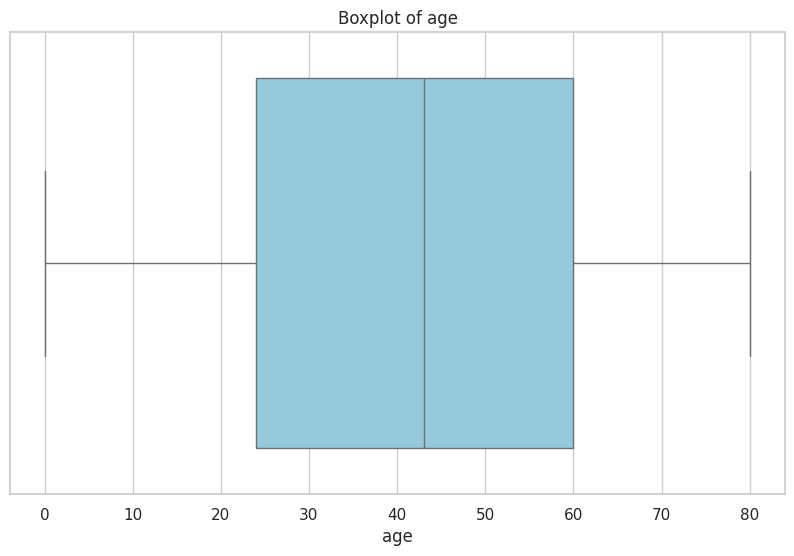

- bmi: 7086 outlier


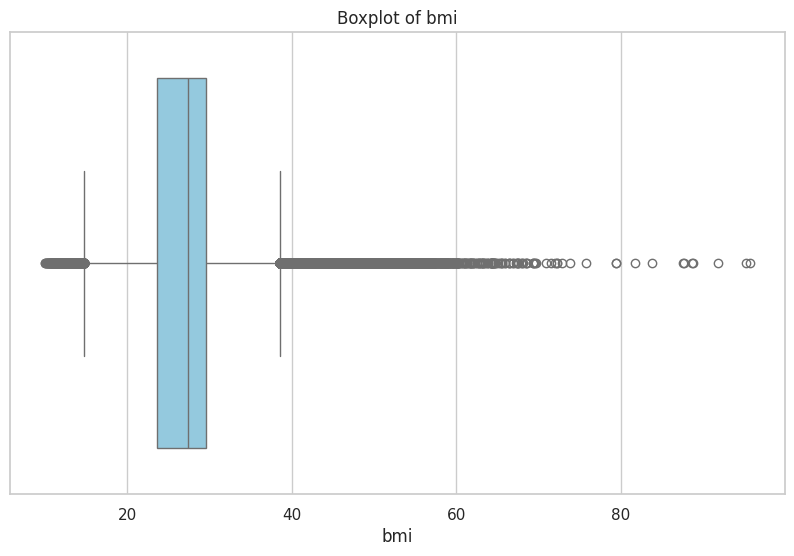

- HbA1c_level: 1315 outlier


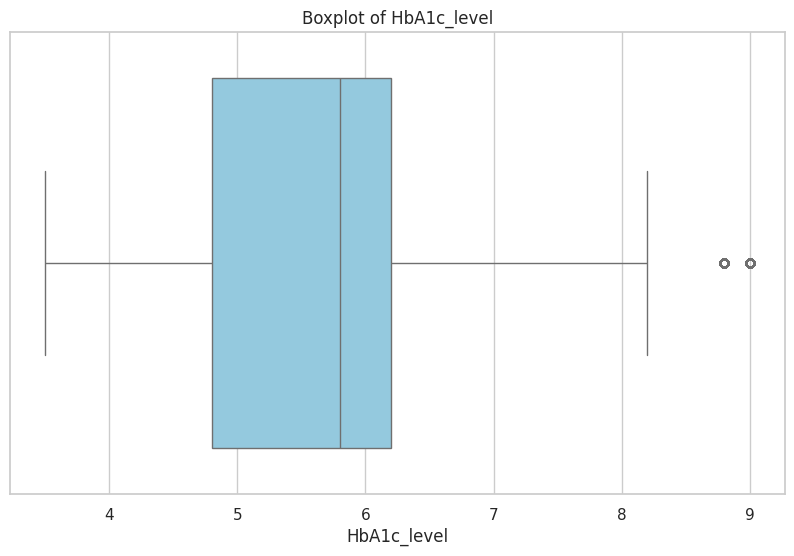

- blood_glucose_level: 2038 outlier


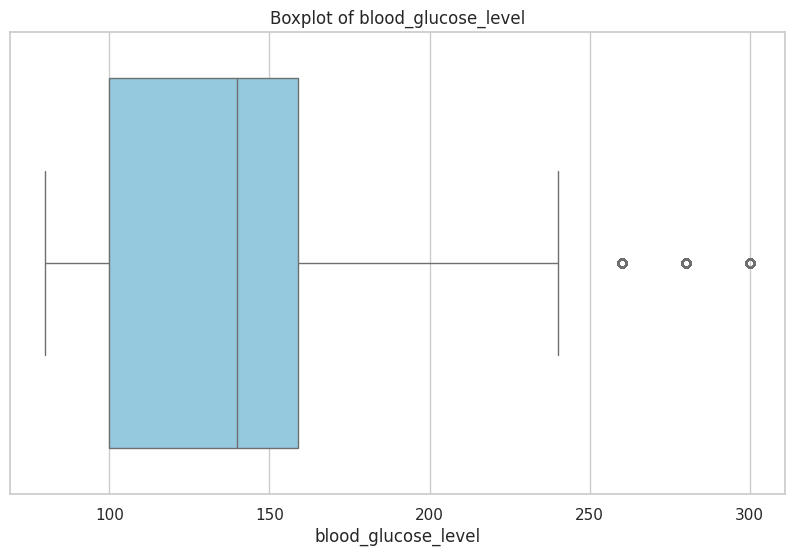

In [ ]:
# Deteksi Outlier (IQR + Boxplot)
num_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

print("Jumlah Outlier per Fitur Numerik:")
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"- {col}: {len(outliers)} outlier")

    # Visualisasi Boxplot
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
    plt.show()

In [ ]:
print(df['bmi'].describe())

count    100000.000000
mean         27.320767
std           6.636783
min          10.010000
25%          23.630000
50%          27.320000
75%          29.580000
max          95.690000
Name: bmi, dtype: float64


In [ ]:
# Clip nilai BMI ke batas medis yang wajar (10–60)
df['bmi'] = df['bmi'].clip(lower=10, upper=60)

Jumlah Outlier per Fitur Numerik:
- age: 0 outlier


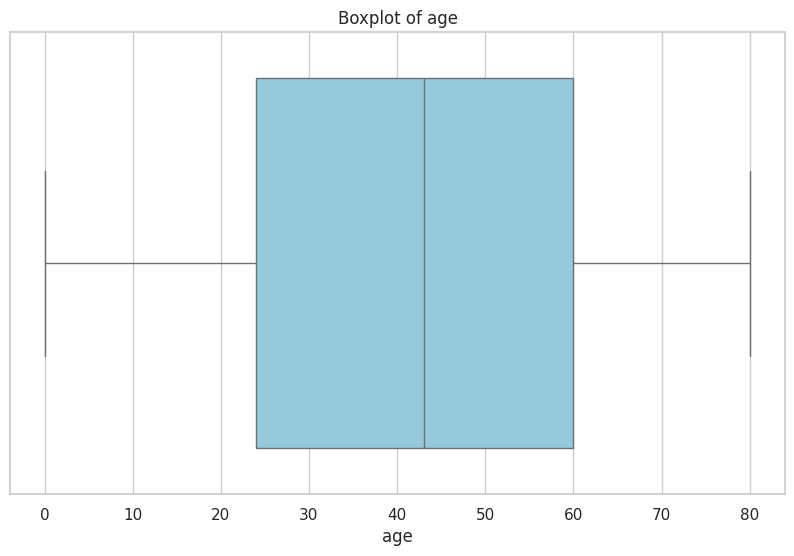

- bmi: 7086 outlier


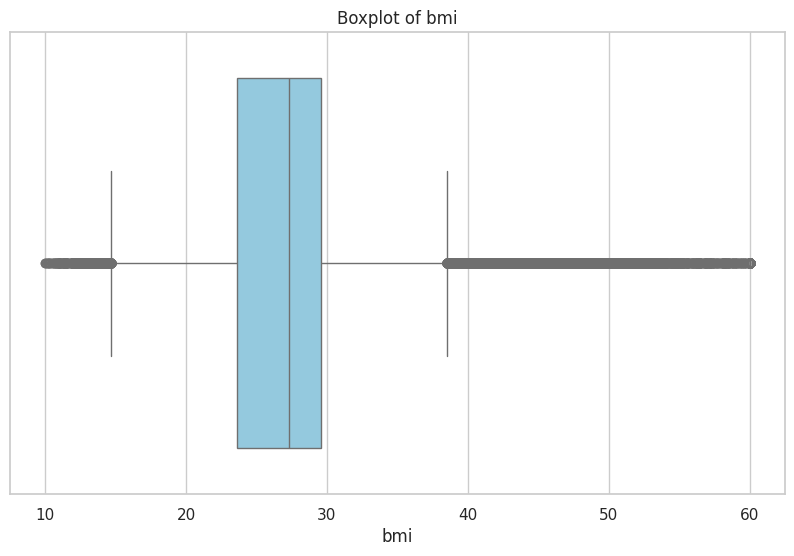

- HbA1c_level: 1315 outlier


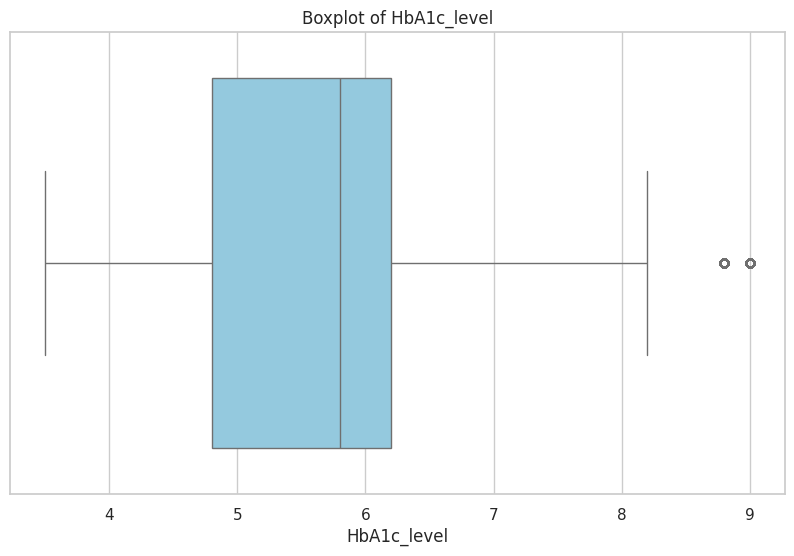

- blood_glucose_level: 2038 outlier


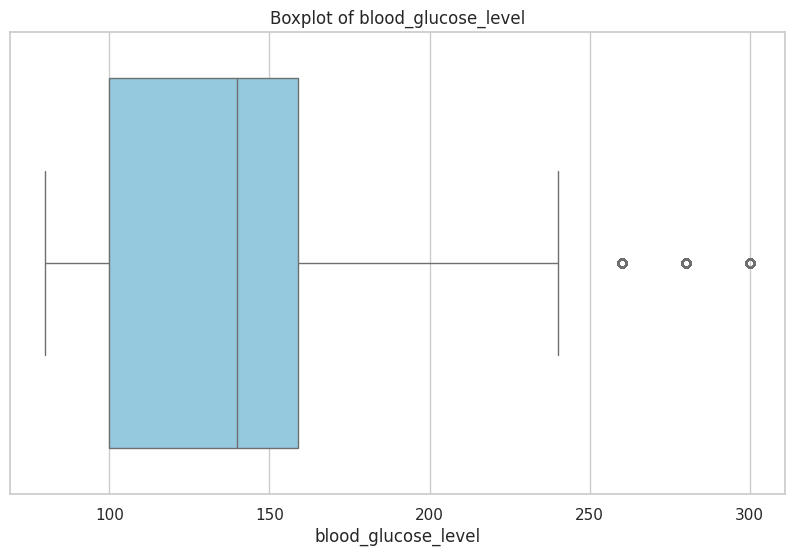

In [ ]:
# Deteksi Outlier (IQR + Boxplot)
num_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

print("Jumlah Outlier per Fitur Numerik:")
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"- {col}: {len(outliers)} outlier")

    # Visualisasi Boxplot
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
    plt.show()

/tmp/ipython-input-6-736061161.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diabetes', data=df, palette='Set2')


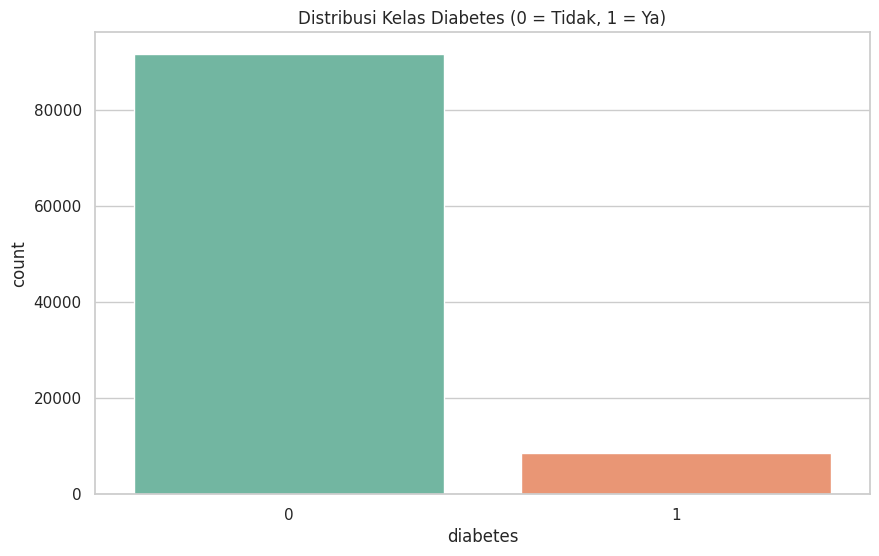

diabetes
0    0.915
1    0.085
Name: proportion, dtype: float64


In [ ]:
# Distribusi Kelas Target
sns.countplot(x='diabetes', data=df, palette='Set2')
plt.title('Distribusi Kelas Diabetes (0 = Tidak, 1 = Ya)')
plt.show()

print(df['diabetes'].value_counts(normalize=True))

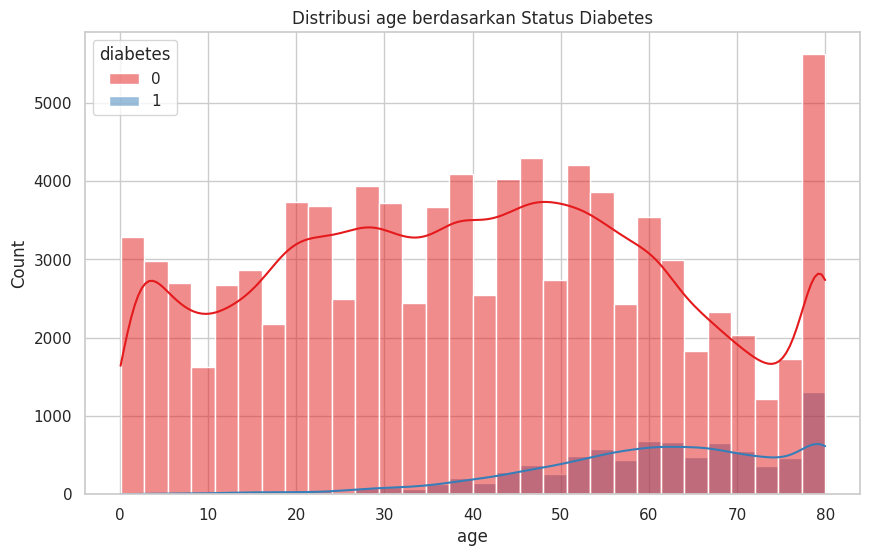

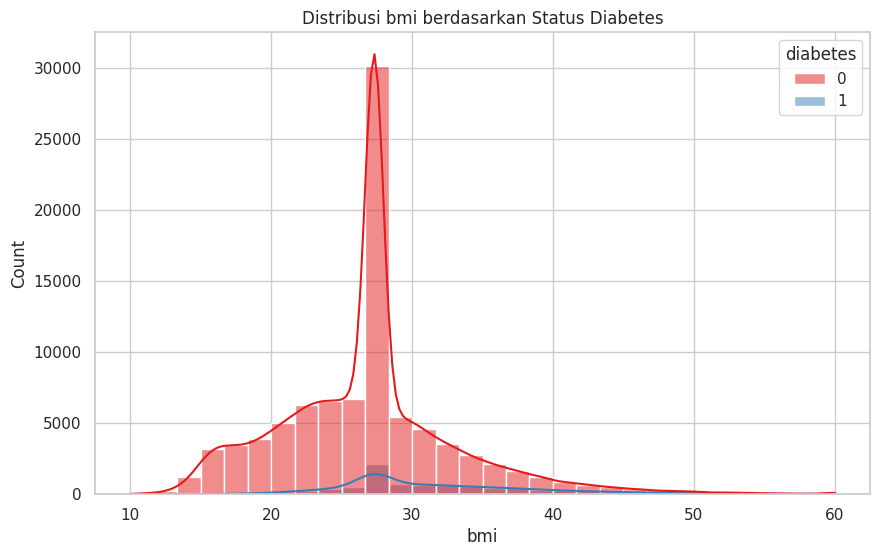

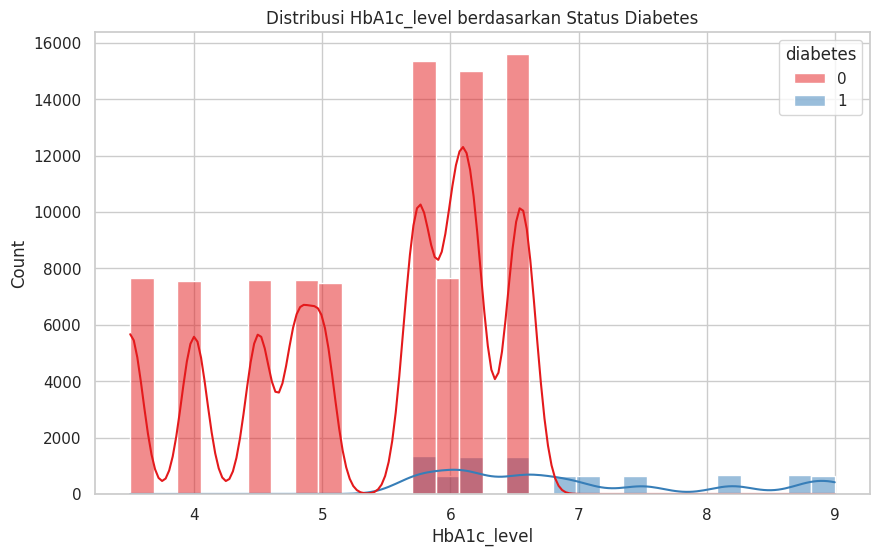

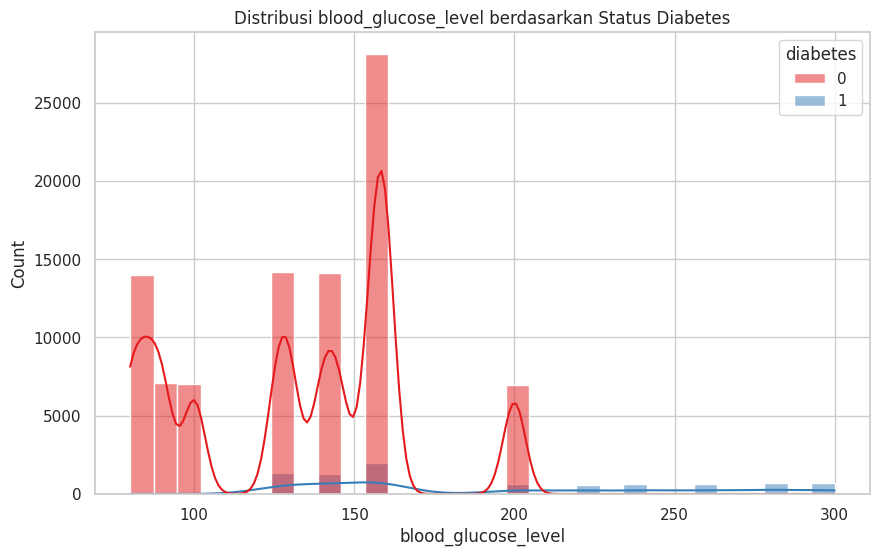

In [ ]:
# Distribusi Fitur Numerik
num_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

for col in num_cols:
    sns.histplot(data=df, x=col, kde=True, hue='diabetes', palette='Set1', bins=30)
    plt.title(f'Distribusi {col} berdasarkan Status Diabetes')
    plt.show()

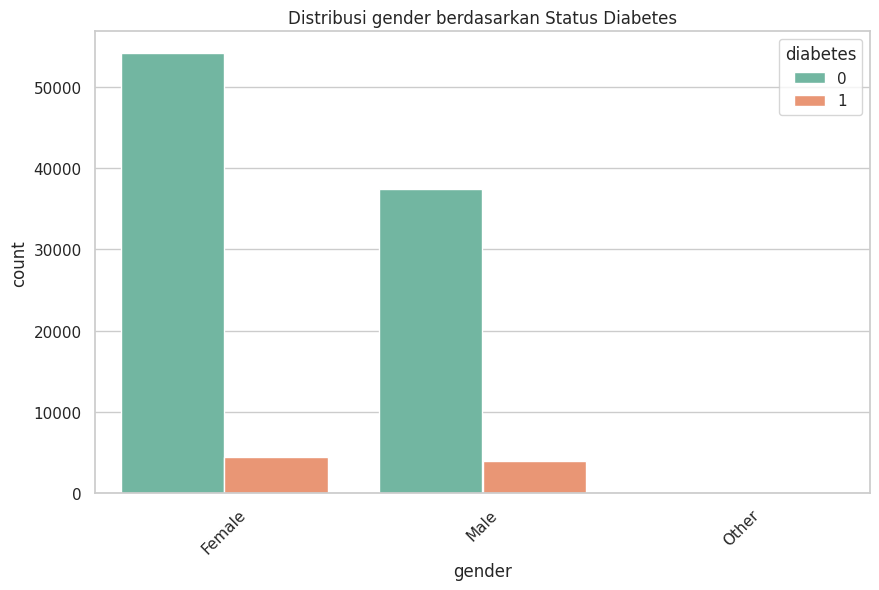

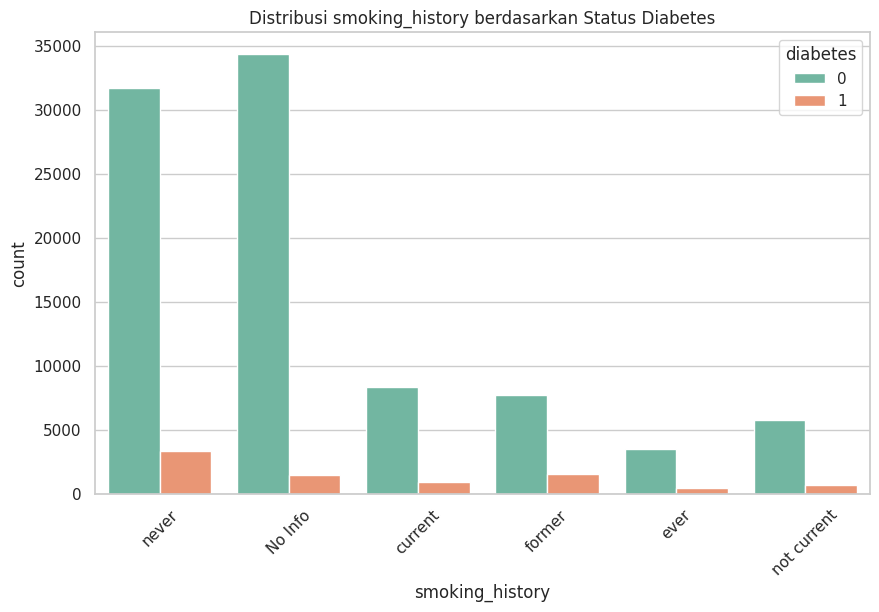

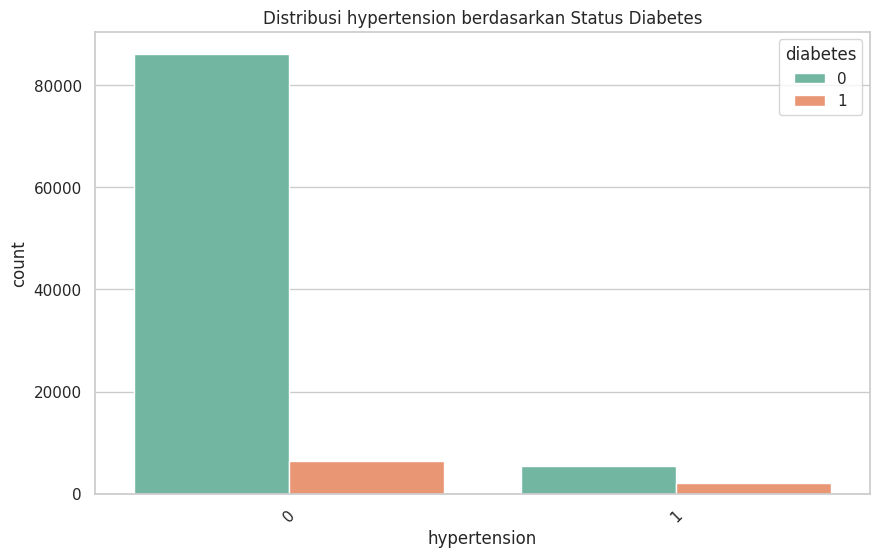

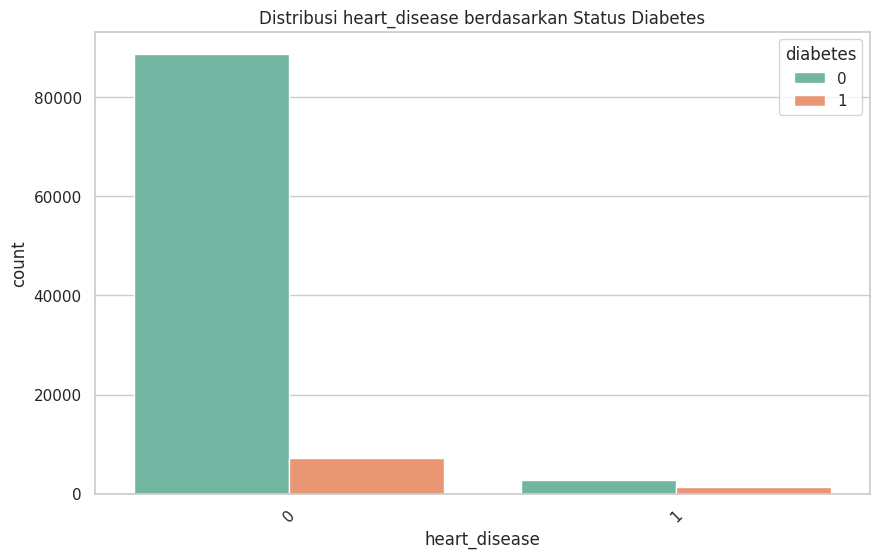

In [ ]:
# Fitur Kategorikal
cat_cols = ['gender', 'smoking_history', 'hypertension', 'heart_disease']

for col in cat_cols:
    sns.countplot(data=df, x=col, hue='diabetes', palette='Set2')
    plt.title(f'Distribusi {col} berdasarkan Status Diabetes')
    plt.xticks(rotation=45)
    plt.show()


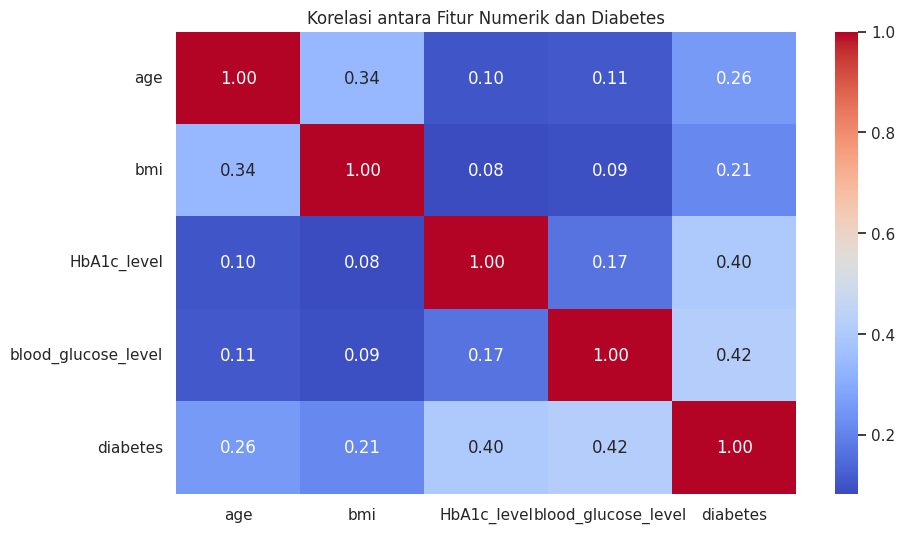

In [ ]:
# Korelasi Fitur Numerik
corr_matrix = df[num_cols + ['diabetes']].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi antara Fitur Numerik dan Diabetes')
plt.show()

Data Preprocessing

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

In [ ]:
# Copy Data & Clip BMI
df_clean = df.copy()
df_clean['bmi'] = df_clean['bmi'].clip(lower=10, upper=60)  # batas medis wajar

In [ ]:
# One-hot encoding untuk 'gender' dan 'smoking_history'

df_encoded = pd.get_dummies(df_clean, columns=['gender', 'smoking_history'], drop_first=True)

In [ ]:
# Pisahkan target dan fitur

# Model 1: Fitur demografis saja
features_demo = ['age', 'hypertension', 'heart_disease'] + \
                [col for col in df_encoded.columns if 'gender_' in col or 'smoking_history_' in col]

X_demo = df_encoded[features_demo]
y = df_encoded['diabetes']

# Model 2: Semua fitur
features_all = features_demo + ['bmi', 'HbA1c_level', 'blood_glucose_level']
X_all = df_encoded[features_all]

In [ ]:
# Split train-test (80-20 stratified)
X_demo_train, X_demo_test, y_demo_train, y_demo_test = train_test_split(
    X_demo, y, test_size=0.2, stratify=y, random_state=42)

X_all_train, X_all_test, y_all_train, y_all_test = train_test_split(
    X_all, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
# SMOTE untuk menangani data imbalance
smote = SMOTE(random_state=42)

X_demo_train_res, y_demo_train_res = smote.fit_resample(X_demo_train, y_demo_train)
X_all_train_res, y_all_train_res = smote.fit_resample(X_all_train, y_all_train)

# Cek distribusi setelah SMOTE
print("Distribusi Kelas (Setelah SMOTE - Demografis):", y_demo_train_res.value_counts().to_dict())
print("Distribusi Kelas (Setelah SMOTE - Semua Fitur):", y_all_train_res.value_counts().to_dict())

Distribusi Kelas (Setelah SMOTE - Demografis): {1: 73200, 0: 73200}
Distribusi Kelas (Setelah SMOTE - Semua Fitur): {1: 73200, 0: 73200}


/tmp/ipython-input-22-1729525125.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_demo_train, ax=ax[0], palette='pastel')
/tmp/ipython-input-22-1729525125.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_demo_train_res, ax=ax[1], palette='Set2')


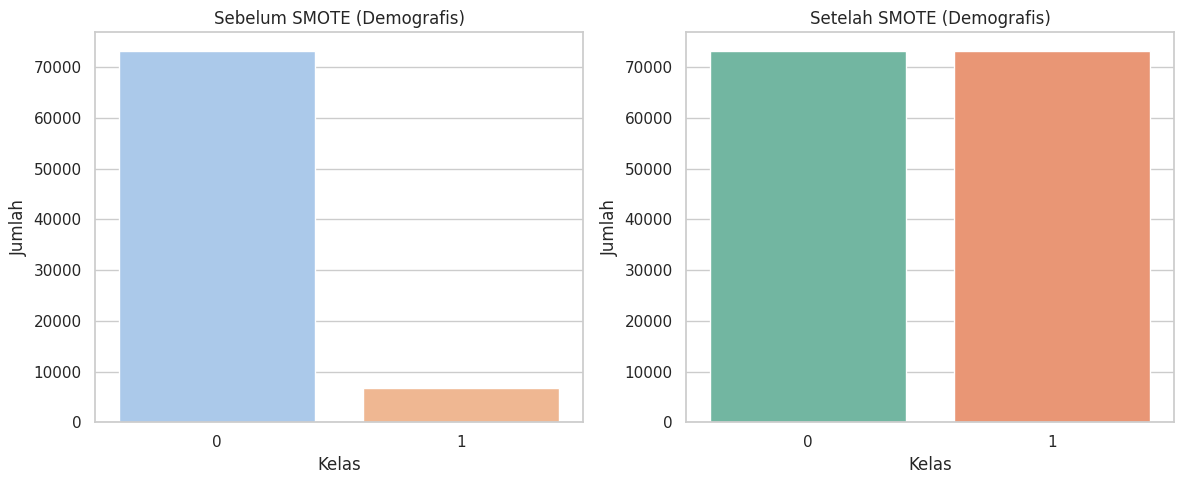

In [ ]:
# Visualisasi Distribusi Kelas Sebelum & Sesudah SMOTE

import matplotlib.pyplot as plt
import seaborn as sns

# Plot distribusi kelas sebelum SMOTE
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x=y_demo_train, ax=ax[0], palette='pastel')
ax[0].set_title("Sebelum SMOTE (Demografis)")
ax[0].set_xlabel("Kelas")
ax[0].set_ylabel("Jumlah")

sns.countplot(x=y_demo_train_res, ax=ax[1], palette='Set2')
ax[1].set_title("Setelah SMOTE (Demografis)")
ax[1].set_xlabel("Kelas")
ax[1].set_ylabel("Jumlah")

plt.tight_layout()
plt.show()


Modeling Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Fungsi Evaluasi
def evaluate_model(model, X_test, y_test, title="Model"):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]  # untuk ROC AUC

    print(f"Performance of {title}")
    print("-" * 40)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("ROC AUC:", roc_auc_score(y_test, y_prob))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {title}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{title} (AUC = {roc_auc_score(y_test, y_prob):.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f"ROC Curve - {title}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

Performance of Gradient Boosting (Demografis)
----------------------------------------
Accuracy: 0.661
ROC AUC: 0.807458662809386

Classification Report:
              precision    recall  f1-score   support

           0     0.9767    0.6449    0.7769     18300
           1     0.1791    0.8341    0.2949      1700

    accuracy                         0.6610     20000
   macro avg     0.5779    0.7395    0.5359     20000
weighted avg     0.9089    0.6610    0.7359     20000



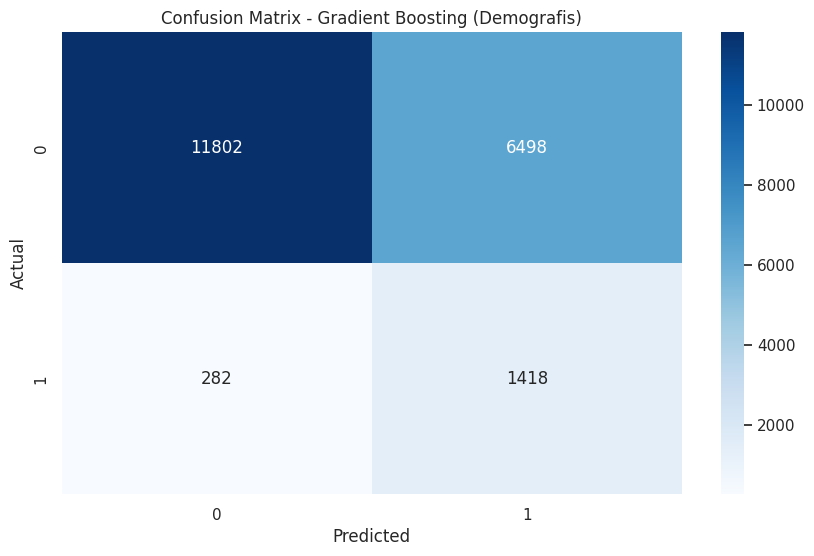

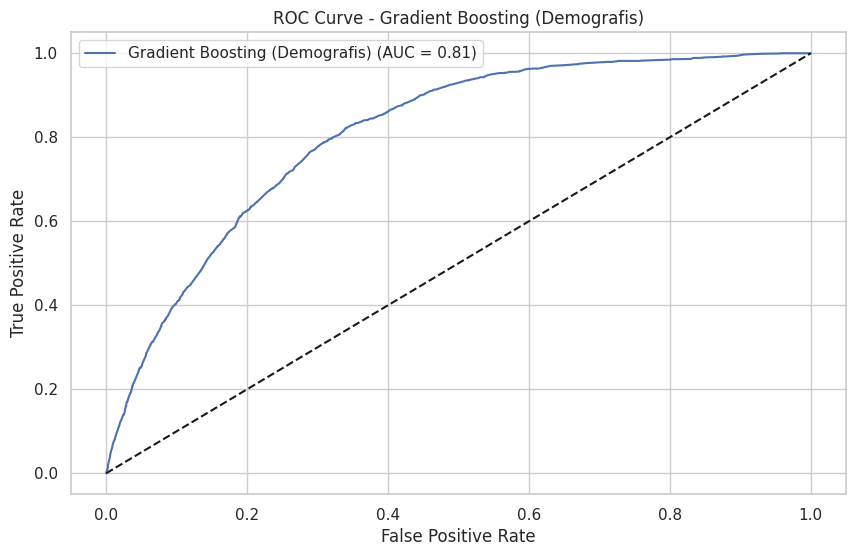

In [ ]:
# Model 1: Demografis Saja
model_demo = GradientBoostingClassifier(random_state=42)
model_demo.fit(X_demo_train_res, y_demo_train_res)

evaluate_model(model_demo, X_demo_test, y_demo_test, title="Gradient Boosting (Demografis)")

Performance of Gradient Boosting (Semua Fitur)
----------------------------------------
Accuracy: 0.95605
ROC AUC: 0.9737612986178078

Classification Report:
              precision    recall  f1-score   support

           0     0.9777    0.9742    0.9759     18300
           1     0.7326    0.7606    0.7463      1700

    accuracy                         0.9560     20000
   macro avg     0.8551    0.8674    0.8611     20000
weighted avg     0.9568    0.9560    0.9564     20000



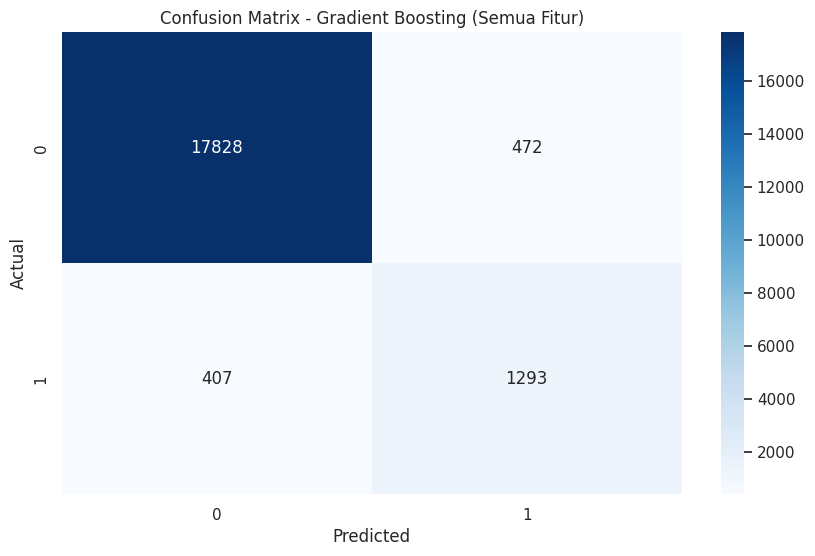

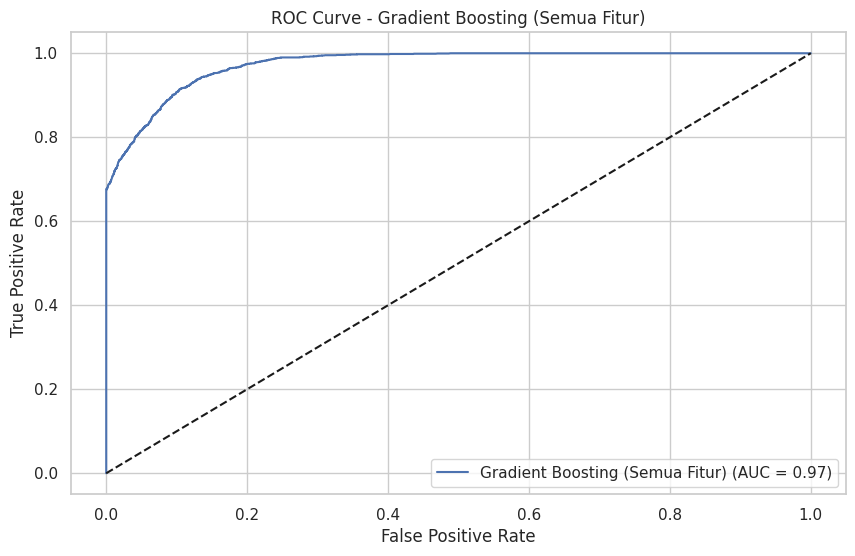

In [ ]:
# Model 2: Semua Fitur
model_all = GradientBoostingClassifier(random_state=42)
model_all.fit(X_all_train_res, y_all_train_res)

evaluate_model(model_all, X_all_test, y_all_test, title="Gradient Boosting (Semua Fitur)")